### This thing moves stress strain files inside output directories (it was not implemented in the running version of the code)

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import shutil
# Get absolute path to raw-data directory (one level up from current directory)
current_dir = Path.cwd()
raw_data_dir = current_dir.parent / 'raw-data'

print(f"Looking for data in: {raw_data_dir}")

# List to store lambda values with f, n, run
stress_dict = []
strain_dict = []

stress = []
strain = []
# Loop over fx folders (f3, f4, f6, etc.)
for f_folder in sorted(raw_data_dir.glob('f*')):
    if not f_folder.is_dir():
        continue
    f_name = f_folder.name
    
    # Loop over Nx folders
    for n_folder in sorted(f_folder.glob('N*')):
        if not n_folder.is_dir():
            continue
        n_name = n_folder.name
        
        # Loop over run0000x folders
        for run_folder in sorted(n_folder.glob('run*')):
            if not run_folder.is_dir():
                continue
            run_name = run_folder.name
            output_folder = run_folder / 'output'
            
            log_file = run_folder / 'stress_strain.txt'
            if log_file.exists():
                # Move file to output directory with step name in filename
                print('exists')
                destination = output_folder
                shutil.move(str(log_file), str(destination))
                print(f"Moved {log_file} to {destination}")
            else:
                print('no stress strain curve in ',output_folder)

Looking for data in: c:\Users\fernando\Nextcloud\PostDoc\IPF\simulation\data\raw-data
no stress strain curve in  c:\Users\fernando\Nextcloud\PostDoc\IPF\simulation\data\raw-data\f3\N16\run00001\output
no stress strain curve in  c:\Users\fernando\Nextcloud\PostDoc\IPF\simulation\data\raw-data\f3\N16\run00002\output
no stress strain curve in  c:\Users\fernando\Nextcloud\PostDoc\IPF\simulation\data\raw-data\f3\N16\run00003\output
no stress strain curve in  c:\Users\fernando\Nextcloud\PostDoc\IPF\simulation\data\raw-data\f3\N16\run00004\output
no stress strain curve in  c:\Users\fernando\Nextcloud\PostDoc\IPF\simulation\data\raw-data\f3\N16\run00005\output
no stress strain curve in  c:\Users\fernando\Nextcloud\PostDoc\IPF\simulation\data\raw-data\f3\N32\run00001\output
no stress strain curve in  c:\Users\fernando\Nextcloud\PostDoc\IPF\simulation\data\raw-data\f3\N32\run00002\output
no stress strain curve in  c:\Users\fernando\Nextcloud\PostDoc\IPF\simulation\data\raw-data\f3\N32\run00003\o

### Stress-strain curves for the first run encountered

Looking for data in: c:\Users\fernando\Nextcloud\PostDoc\IPF\simulation\data\raw-data


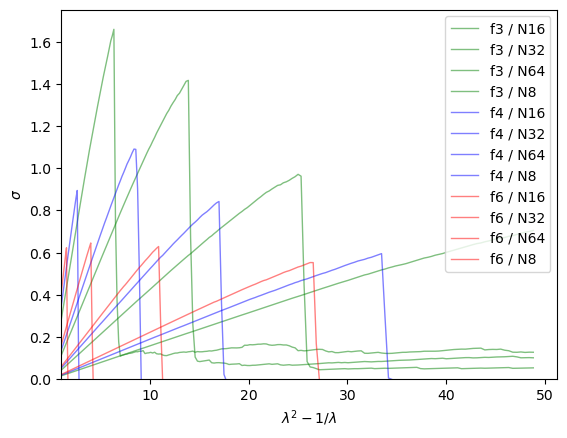

In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
# Get absolute path to raw-data directory (one level up from current directory)
current_dir = Path.cwd()
raw_data_dir = current_dir.parent / 'raw-data'

print(f"Looking for data in: {raw_data_dir}")

# List to store lambda values with f, n, run
# Loop over fx folders (f3, f4, f6, etc.)
for f_folder in sorted(raw_data_dir.glob('f*')):
    if not f_folder.is_dir():
        continue
    f_name = f_folder.name
    
    # Loop over Nx folders
    for n_folder in sorted(f_folder.glob('N*')):
        if not n_folder.is_dir():
            continue
        n_name = n_folder.name
        
        # Loop over run0000x folders
        test = 1

        for run_folder in sorted(n_folder.glob('run*')):
            if not run_folder.is_dir():
                continue
            run_name = run_folder.name
            
            output_folder = run_folder / 'output'
            
            # Look for breakage_log.txt
            log_file = output_folder / 'stress_strain.txt'
            if log_file.exists() and test==1:
                data = np.loadtxt(log_file, delimiter="\t", skiprows=1)
                strain = data[:, 0]
                strain = strain**2-1/strain
                stress = data[:, 1]
                if int(f_name[1:]) == 3:
                    plt.plot(strain,stress,label=f"{f_name} / {n_name}",color='green',alpha=0.5,linewidth=1)
                if int(f_name[1:]) == 4:
                    plt.plot(strain,stress,label=f"{f_name} / {n_name}",color='blue',alpha=0.5,linewidth=1)
                if int(f_name[1:]) == 6:
                    plt.plot(strain,stress,label=f"{f_name} / {n_name}",color='red',alpha=0.5,linewidth=1)
                test = 0
plt.xlabel(r'$\lambda^2-1/\lambda$')
plt.ylabel(r'$\sigma$')
plt.xlim(left=1)
plt.ylim(bottom=0)
plt.legend()
plt.show()


### Extract breakage deformation, averages over runs and plot against N

<>:39: SyntaxWarning: invalid escape sequence '\s'
<>:39: SyntaxWarning: invalid escape sequence '\s'
C:\Users\fernando\AppData\Local\Temp\ipykernel_15312\936726760.py:39: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(log_file, sep='\s',names=['step', 'lambda', 'cumulative_broken', 'remaining','stress'],


Looking for data in: c:\Users\fernando\Nextcloud\PostDoc\IPF\simulation\data\raw-data
f=3, N=[8, 16, 32, 64], lambda=[2.8899999999999997, 3.91, 5.349999999999999, 7.0], std=[0.1894125454440281, 0.0, 1.8338589356726246e-15, 0.0]
f=4, N=[8, 16, 32, 64], lambda=[1.8699999999999999, 2.8825, 4.024, 6.142], std=[0.03502981722047999, 0.2383325175532907, 0.13924076950772646, 0.2221011963022931]
f=6, N=[8, 16, 32, 64], lambda=[1.5599999999999998, 2.272, 3.4, 5.104], std=[0.10528157733587278, 0.07178976247976455, 0.11964960413294093, 0.23094897526137045]


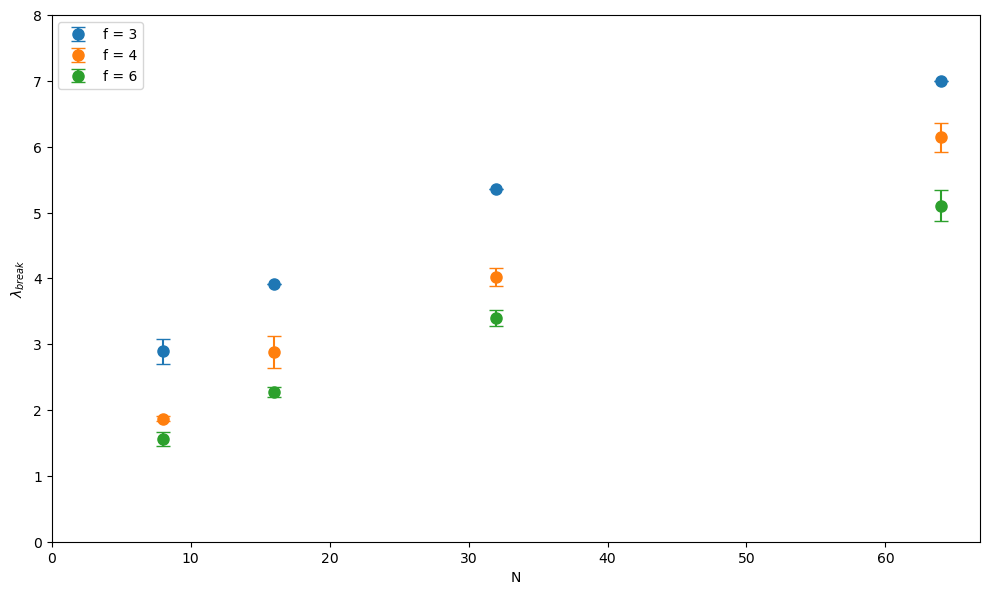

In [3]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
# Get absolute path to raw-data directory (one level up from current directory)
current_dir = Path.cwd()
raw_data_dir = current_dir.parent / 'raw-data'

print(f"Looking for data in: {raw_data_dir}")

# List to store lambda values with f, n, run
lambda_break = []
strain = []
broken = []
# Loop over fx folders (f3, f4, f6, etc.)
for f_folder in sorted(raw_data_dir.glob('f*')):
    if not f_folder.is_dir():
        continue
    f_name = f_folder.name
    
    # Loop over Nx folders
    for n_folder in sorted(f_folder.glob('N*')):
        if not n_folder.is_dir():
            continue
        n_name = n_folder.name
        
        # Loop over run0000x folders
        for run_folder in sorted(n_folder.glob('run*')):
            if not run_folder.is_dir():
                continue
            run_name = run_folder.name
            output_folder = run_folder / 'output'
            
            # Look for breakage_log.txt
            log_file = output_folder / 'breakage_log.txt'
            if log_file.exists():
                if True:
                    df = pd.read_csv(log_file, sep='\s',names=['step', 'lambda', 'cumulative_broken', 'remaining','stress'],
                                     engine='python',header=1)

                                        # Convert to proper data types
                    df['step'] = pd.to_numeric(df['step'], errors='coerce')
                    df['lambda'] = pd.to_numeric(df['lambda'], errors='coerce')
                    df['cumulative_broken'] = pd.to_numeric(df['cumulative_broken'], errors='coerce')
                    df['remaining'] = pd.to_numeric(df['remaining'], errors='coerce')
                    df['stress'] = pd.to_numeric(df['stress'], errors='coerce')
                    if len(df) > 0:
                        last_row = df.iloc[-1].tolist()
                        last_row = [float(x) for x in last_row]
                        lambda_val = last_row[1]
                        
                        total_bonds = last_row[2] + last_row[3]

                        # Store f, n, run, and lambda
                        lambda_break.append({
                            'f': int(f_name[1:]),  # Remove 'f' prefix
                            'n': int(n_name[1:]),  # Remove 'N' prefix
                            'run': int(run_name[7:]),  # Remove 'run' prefix
                            'lambda': lambda_val
                        })
                        strain_each = df['lambda'].values
                        strain.append({
                            'f': int(f_name[1:]),  # Remove 'f' prefix
                            'n': int(n_name[1:]),  # Remove 'N' prefix  
                            'run': int(run_name[7:]),  # Remove 'run' prefix
                            'strain': strain_each
                        })
                        broken.append({
                            'f': int(f_name[1:]),  # Remove 'f' prefix
                            'n': int(n_name[1:]),  # Remove 'N' prefix
                            'run': int(run_name[7:]),  # Remove 'run' prefix
                            'broken': df['cumulative_broken'].values
                        })


                        #print(f"{f_name}/{n_name}/{run_name}: lambda = {lambda_val}")

# Group data by f and N, and average lambda values across runs
f_values = {}
for entry in lambda_break:
    f = entry['f']
    n = entry['n']
    
    if f not in f_values:
        f_values[f] = {}
    
    if n not in f_values[f]:
        f_values[f][n] = []
    
    f_values[f][n].append(entry['lambda'])

# Average the lambda values for each (f, N) pair and compute standard deviation with t-student correction
f_values_averaged = {}
for f, n_data in f_values.items():
    f_values_averaged[f] = {'N': [], 'lambda': [], 'std': []}
    #if f == 3:
    #    continue
    for n in sorted(n_data.keys()):
        f_values_averaged[f]['N'].append(n)
        avg_lambda = sum(n_data[n]) / len(n_data[n])
        std_lambda = np.std(n_data[n], ddof=1)  # Sample standard deviation
        n_samples = len(n_data[n])
        # T-student correction: SE = std / sqrt(n) * t_critical
        se_lambda = std_lambda / np.sqrt(n_samples) * stats.t.ppf(0.95, n_samples - 1)
        f_values_averaged[f]['lambda'].append(avg_lambda)
        f_values_averaged[f]['std'].append(se_lambda)
        
# Create the plot
plt.figure(figsize=(10, 6))

# Plot each f with a different color and error bars
for f, data in sorted(f_values_averaged.items()):
    plt.errorbar(data['N'], data['lambda'], yerr=data['std'], marker='o', linestyle='none', label=f'f = {f}', markersize=8, capsize=5)
    print(f"f={f}, N={data['N']}, lambda={data['lambda']}, std={data['std']}")
plt.xlabel('N')
plt.ylabel(r'$\lambda_{break}$')
plt.legend()
plt.tight_layout()
plt.xlim(left=0)
plt.ylim(bottom=0,top=8)
plt.savefig('lambda_break_vs_N.png', dpi=300)
plt.show()


### This thing plots average percentage of broken bonds against deformation

Plotted f=3, N=8, strain points=62, broken points=62
[1.   1.06 1.09 1.12 1.15 1.18 1.21 1.24 1.27 1.3  1.33 1.36 1.39 1.42
 1.45 1.48 1.51 1.54 1.57 1.6  1.63 1.66 1.69 1.72 1.75 1.78 1.81 1.84
 1.87 1.9  1.93 1.96 1.99 2.02 2.05 2.08 2.11 2.14 2.17 2.2  2.23 2.26
 2.29 2.32 2.35 2.38 2.41 2.44 2.47 2.5  2.53 2.56 2.59 2.62 2.65 2.68
 2.71 2.74 2.77 2.8  2.83 2.86]
[    0.    999.    999.    999.    999.    999.    999.5  1001.5  1004.5
  1008.   1008.   1008.5  1009.5  1009.5  1013.5  1015.   1015.   1017.
  1017.5  1017.5  1018.5  1019.   1019.5  1021.   1023.   1024.   1027.5
  1030.   1033.   1039.   1042.   1051.   1101.   1107.5  1113.5  1127.
  1142.5  1158.   1171.5  1198.5  1217.5  1239.   1265.5  1296.   1330.
  1371.5  1415.   1442.   1573.   1609.   1645.   3064.5  3445.   9579.5
  9849.5  9953.5  9987.   9989.5 10003.5 10015.5 10024.5 10029. ]
Plotted f=3, N=16, strain points=97, broken points=97
[1.   1.06 1.09 1.12 1.15 1.18 1.21 1.24 1.27 1.3  1.33 1.36 1.39 1.42
 1.45

(0.0, 10.0)

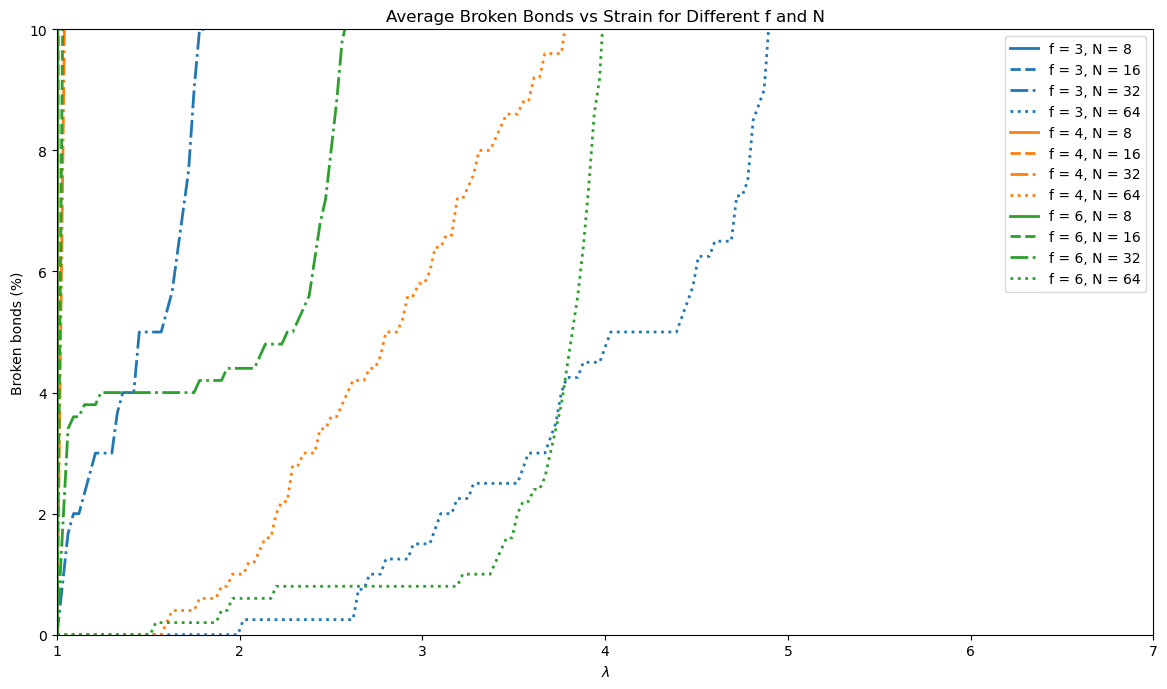

In [5]:
# Group broken data by f and n, and average across runs
broken_averaged = {}

for b in broken:
    f = b['f']
    n = b['n']
    key = (f, n)
    
    if key not in broken_averaged:
        broken_averaged[key] = []
    
    broken_averaged[key].append(b['broken'])

# Average the broken arrays for each (f, n) pair
broken_avg_by_fn = {}
for key, broken_arrays in broken_averaged.items():
    f, n = key
    # arrays may have different lengths (different run durations);
    # trim them to the shortest before averaging
    lengths = [arr.shape[0] for arr in broken_arrays]
    min_len = min(lengths)
    trimmed = np.vstack([arr[:min_len] for arr in broken_arrays])
    avg_broken = np.mean(trimmed, axis=0)

    broken_avg_by_fn[key] = avg_broken


# Group strain data by f and n, and average across runs
strain_averaged = {}

for s in strain:
    f = s['f']
    n = s['n']
    key = (f, n)
    
    if key not in strain_averaged:
        strain_averaged[key] = []
    
    strain_averaged[key].append(s['strain'])

# Average the strain arrays for each (f, n) pair (trim to shortest)
strain_avg_by_fn = {}
for key, strain_arrays in strain_averaged.items():
    f, n = key
    # Trim to shortest length
    lengths = [arr.shape[0] for arr in strain_arrays]
    min_len = min(lengths)
    trimmed = np.vstack([arr[:min_len] for arr in strain_arrays])
    avg_strain = np.mean(trimmed, axis=0)
    strain_avg_by_fn[key] = avg_strain

# Get unique f and n values
unique_f = sorted(set([key[0] for key in broken_avg_by_fn.keys()]))
unique_n = sorted(set([key[1] for key in broken_avg_by_fn.keys()]))

# Define linestyles for different N values
linestyles = ['-', '--', '-.', ':']
linestyle_dict = {n: linestyles[i % len(linestyles)] for i, n in enumerate(unique_n)}

# Create the plot
plt.figure(figsize=(12, 7))

# Plot each (f, n) combination
colors = plt.cm.tab10(range(len(unique_f)))
for f_idx, f in enumerate(unique_f):
    for n in unique_n:
        key = (f, n)
        if key in broken_avg_by_fn and key in strain_avg_by_fn:
            avg_strain = strain_avg_by_fn[key]
            avg_broken = broken_avg_by_fn[key]
            
            # Add initial conditions: at strain=1, broken=0%
            avg_strain_with_init = np.concatenate([[1.0], avg_strain])
            avg_broken_with_init = np.concatenate([[0.0], avg_broken])
            if f == 3 and n == 16:
                avg_strain_with_init = avg_strain_with_init[:97]
                avg_broken_with_init = avg_broken_with_init[:97]
            if f == 3 and n == 32:
                avg_strain_with_init = avg_strain_with_init[:145]
                avg_broken_with_init = avg_broken_with_init[:145]
            plt.plot(avg_strain_with_init, avg_broken_with_init, color=colors[f_idx], 
                    linestyle=linestyle_dict[n], linewidth=2, 
                    label=f'f = {f}, N = {n}')
            print(f"Plotted f={f}, N={n}, strain points={len(avg_strain_with_init)}, broken points={len(avg_broken_with_init)}")
            data = np.column_stack((avg_strain_with_init, avg_broken_with_init))
            pd.DataFrame(data).to_clipboard(index=False, header=False)
            print(avg_strain_with_init)
            print(avg_broken_with_init)
            input("Press Enter to continue...")
plt.xlabel(r'$\lambda$')
plt.ylabel('Broken bonds (%)')
plt.title('Average Broken Bonds vs Strain for Different f and N')
plt.legend()
plt.tight_layout()
plt.savefig('broken_bonds_vs_strain.png', dpi=300)
plt.xlim(left=1, right=7)
plt.ylim(bottom=0,top = 10)

### This thing adapts plotterv1.py to take only one file

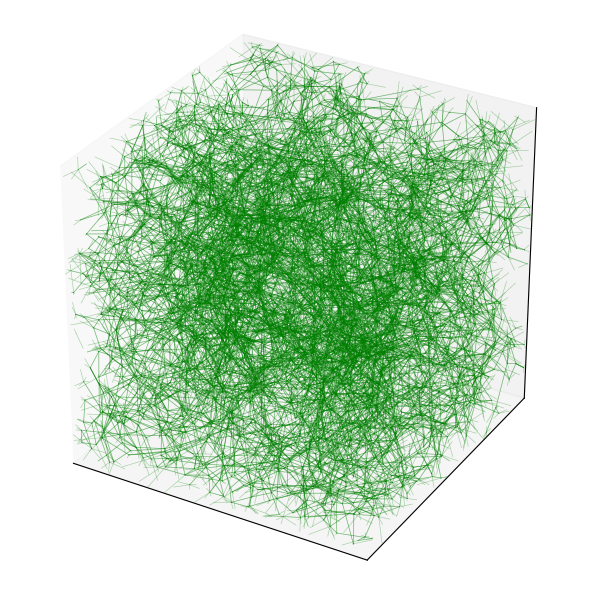

Plotting completed in 0.63 minutes.
Done.


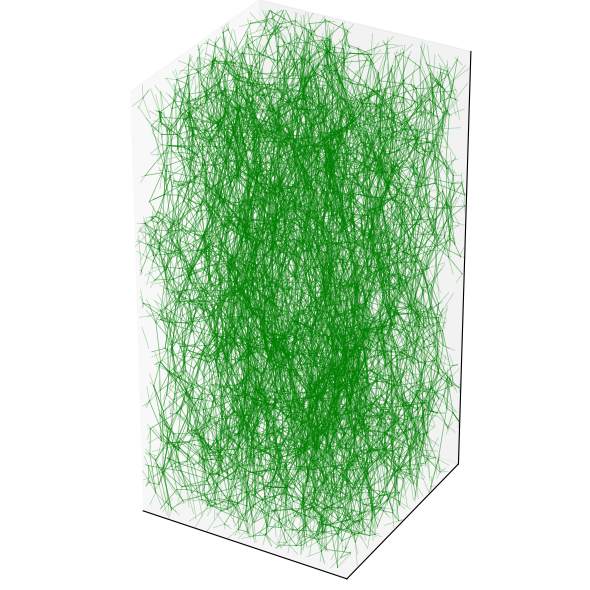

Plotting completed in 0.68 minutes.
Done.


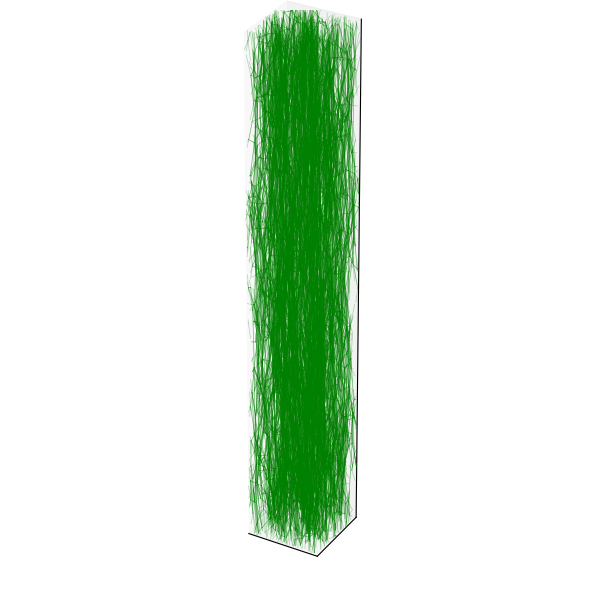

Plotting completed in 0.68 minutes.
Done.


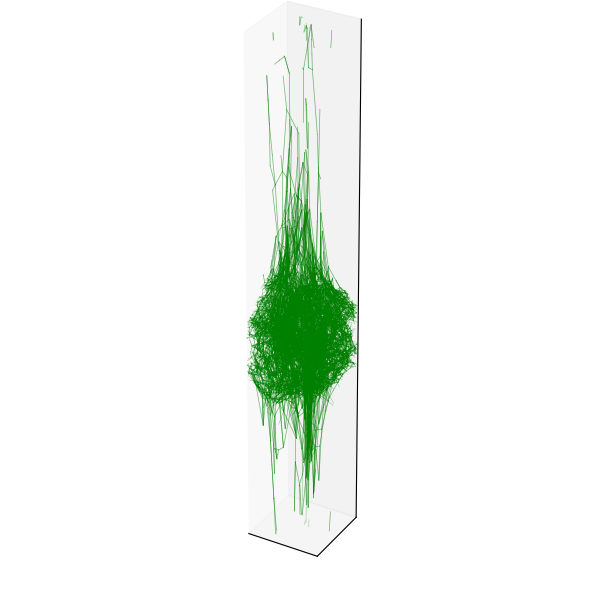

Plotting completed in 0.64 minutes.
Done.


In [4]:
import numpy as np
from matplotlib import pyplot as plt
import time 
from pathlib import Path

def count_bonds(connections):
    bonds = set()
    for i in range(len(connections)):
        for k in range(connections.shape[1]):
            conn_val = connections[i, k]
            if conn_val != -1 and conn_val != i:  # skip invalid and self
                # Add as sorted tuple to avoid double-counting
                bond = tuple(sorted([i, conn_val]))
                bonds.add(bond)
    return len(bonds)

def plot_connection_with_pbc(ax, pos1, pos2, box, color, alpha, linewidth):
    """Plot connection respecting minimum image convention"""
    delta = pos2 - pos1
    delta = (delta + 0.5 * box) % box - 0.5 * box  # Wrap to [-box/2, box/2]
    endpoint = pos1 + delta
    crosses_boundary = np.any((endpoint < 0) | (endpoint > box))
    
    if crosses_boundary and np.any(delta != 0):
        # Find which boundary we hit first
        t_upper = np.where(delta > 0, (box - pos1) / delta, np.inf)
        t_lower = np.where(delta < 0, -pos1 / delta, np.inf)
        
        # Take minimum t across all dimensions (first boundary hit)
        t = np.min(np.concatenate([t_upper, t_lower]))
        
        # Calculate boundary intersection point
        boundary_point = pos1 + t * delta
        
        # Clip to ensure it's exactly on boundary
        boundary_point = np.clip(boundary_point, 0, box)
        
        # Plot line from pos1 to boundary projection
        ax.plot([pos1[0], boundary_point[0]],
                [pos1[1], boundary_point[1]],
                [pos1[2], boundary_point[2]], 
                color=color, alpha=alpha, linewidth=linewidth)
    else:
        # Normal connection stays within box
        ax.plot([pos1[0], endpoint[0]],
                [pos1[1], endpoint[1]],
                [pos1[2], endpoint[2]], 
                color=color, alpha=alpha, linewidth=linewidth)

current_dir = Path.cwd()
raw_data_dir = current_dir.parent / 'raw-data'

steps = [1,35,98,140]

for a in range(len(steps)):
    if steps[a] == 1:
        target_dir = raw_data_dir / 'f6' / 'N64' / 'run00001' / 'output' / 'step_000{}'.format(str(steps[a]))
    if steps[a] == 35:
        target_dir = raw_data_dir / 'f6' / 'N64' / 'run00001' / 'output' / 'step_00{}'.format(steps[a])
    if steps[a] == 98:
        target_dir = raw_data_dir / 'f6' / 'N64' / 'run00001' / 'output' / 'step_00{}'.format(steps[a])
    if steps[a] == 140:
        target_dir = raw_data_dir / 'f6' / 'N64' / 'run00001' / 'output' / 'step_0{}'.format(steps[a])
    t0 = time.time()


    # Load data
    positions = np.loadtxt(target_dir / 'positions.txt')
    remaining = np.loadtxt(target_dir / 'connections.txt', dtype=int)
    box_curr = np.loadtxt(target_dir / 'box.txt')

    connectionsCurr = count_bonds(remaining)  # total number of connections after breakage

    # Load broken connections
    if (target_dir / 'broken_connections.txt').exists():
        broken = np.loadtxt(target_dir / 'broken_connections.txt', dtype=int)

    # Sort each row to ensure consistent ordering [smaller_id, larger_id]
        sorted_broken = np.sort(broken, axis=1)

        # Find unique bonds
        unique_broken, counts_broken = np.unique(sorted_broken, axis=0, return_counts=True)

        # Total unique broken connections
        connectionsBroken = len(unique_broken)



    fig = plt.figure(figsize=(14, 6))

    # Box 1: Remaining connections
    ax1 = fig.add_subplot(121, projection='3d')

    for row in remaining:
        i = row[0]
        for k in range(1, len(row)):
            conn = row[k]
            if conn != -1 and i != conn:  # valid connection and not self
                plot_connection_with_pbc(ax1, positions[i], positions[conn], 
                                        box_curr, 'g', 0.3, 0.5)

    ax1.set_xlim(0, box_curr[0])
    ax1.set_ylim(0, box_curr[1])
    ax1.set_zlim(0, box_curr[2])
    ax1.grid(False)
    if steps[a] == 1:
        ax1.set_box_aspect((1, 1, 1))
    if steps[a] == 35:
        ax1.set_box_aspect((1, 1, 2))
    if steps[a] == 98:
        ax1.set_box_aspect((1, 1, 7))
    if steps[a] == 140:
        ax1.set_box_aspect((1, 1, 7))

    ax1.set_xticks([])                               
    ax1.set_yticks([])                               
    ax1.set_zticks([])
    plt.tight_layout()
    plt.savefig(target_dir / f'Box-deformed_{steps[a]}.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

    print(f"Plotting completed in {(time.time() - t0)/60:.2f} minutes.")
    print('Done.')

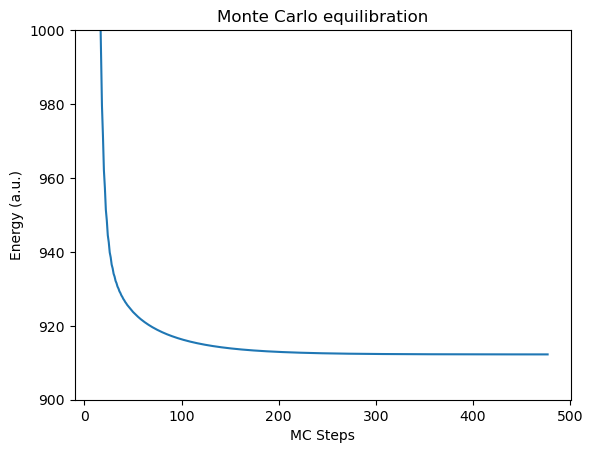

In [11]:
import numpy as np

energy_list = np.loadtxt('energy_list.txt')

steps = energy_list[:,0]
energy = energy_list[:,1]

import matplotlib.pyplot as plt

plt.plot(steps, energy)

plt.xlabel('MC Steps')
plt.ylabel('Energy (a.u.)')
plt.title('Monte Carlo equilibration')
plt.xlim(left=-10)
plt.ylim(bottom=900,top=1000)
plt.show()